# LAB10 — Variacioni i Performancës së Kompjuterit
---
- ##### Tema: **Koha e ekzekutimit si madhësi statistikore (jitter).**
- ##### Studenti: Florian Loka
- ##### Pedagogu: Ervin Kafexhiu
- ##### Data: 19.05.2026
---


## **Qëllimi (Purpose)**

Në LAB09 supozuam se për një input të dhënë kemi një kohë të vetme $T(n)$. Këtu tregojmë
se në realitet **i njëjti kod me të njëjtin input jep kohë të ndryshme** nga ekzekutimi
në ekzekutim:

$$ T(n)\ \text{nuk është konstante} \;\Rightarrow\; T(n)\sim \text{shpërndarje} $$

Synojmë të **fiksojmë** $n$, ta përsërisim matjen shumë herë dhe ta karakterizojmë
variacionin statistikisht.


## **Hyrje Teorike (Theory)**

Koha e ekzekutimit ndikohet nga faktorë fizikë dhe sistemorë:

- **CPU:** ndryshime frekuence (turbo boost), ndarje midis proceseve.
- **Memoria:** *cache hit/miss*, lokaliteti i të dhënave.
- **Sistemi Operativ:** *scheduler*, ndërprerje, procese në sfond.
- **I/O & të jashtëm:** akses në disk, temperatura, *power management*.

Pra matja ka **zhurmë (jitter)** reale. Trajtojmë \(T\) si madhësi statistikore dhe
e përshkruajmë me mesataren \(\bar T\), devijimin standard \(\sigma\), si dhe
minimumin/maksimumin. Ky është analog i drejtpërdrejtë i çdo matjeje fizike me gabim.


## **Aparatura dhe Pajisjet (Apparatus)**

- Kompjuter me Python (Jupyter Notebook).
- Matësi `time.perf_counter()` (rezolucion i lartë).
- Ngarkesa: shuma e numrave deri në **n = 100 000** (input fiks).

Matja u përsërit shumë herë pas një faze *warm-up*; çdo kohë u ruajt veçmas në
`data/timing_repeat.csv`.


## **Procedura (Procedure)**

1. Zgjodhëm një ngarkesë të thjeshtë (shumë e një cikli) me **input fiks** $n=10^5$.
2. Kryem disa ekzekutime *warm-up* për të stabilizuar *cache*-in e CPU-së.
3. Përsëritëm matjen me `perf_counter()` **400 herë**, pa `print` brenda matjes.
4. Ruajtëm çdo vlerë $T_i$ në `data/timing_repeat.csv`.
5. Analizuam shpërndarjen: histogram, mesatare, devijim standard, min/max, *outliers*.


## **Përpunimi Paraprak i të Dhënave (Preprocessing)**

Ngarkojmë serinë e matjeve nga `data/` dhe e shndërrojmë në milisekonda për lexueshmëri.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)

df = pd.read_csv("data/timing_repeat.csv")
df["T_ms"] = df["T_s"] * 1e3
T = df["T_ms"].to_numpy()
print("Numri i matjeve:", len(T))
print(df["T_ms"].describe().round(4))

Numri i matjeve: 400
count    400.0000
mean       2.1769
std        0.4738
min        2.0372
25%        2.0576
50%        2.0938
75%        2.1511
max        6.5778
Name: T_ms, dtype: float64


## **Analiza e të Dhënave (Analysis)**

Llogarisim madhësitë statistikore dhe ndërtojmë histogramin (densitet) me kurbën Gaussiane.

Mesatarja  T̄  = 2.1769 ms
Mediana       = 2.0938 ms
Devijimi σ    = 0.4738 ms   (21.8 % e mesatares)
Min / Max     = 2.0372 / 6.5778 ms


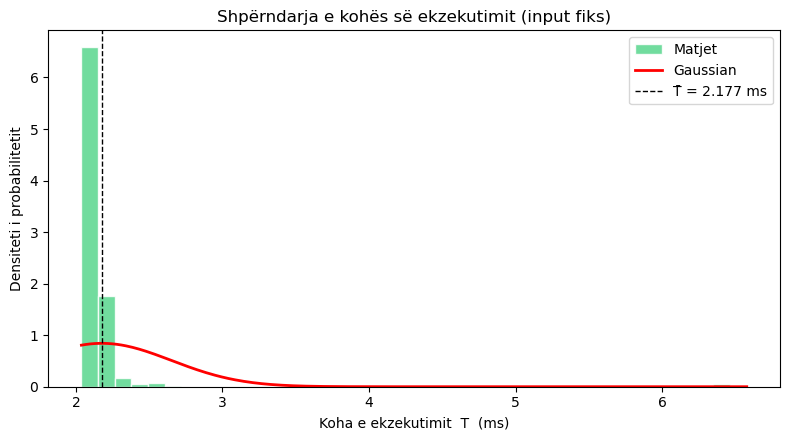

In [2]:
mu, sd = T.mean(), T.std(ddof=1)
Tmin, Tmax, med = T.min(), T.max(), np.median(T)
print(f"Mesatarja  T̄  = {mu:.4f} ms")
print(f"Mediana       = {med:.4f} ms")
print(f"Devijimi σ    = {sd:.4f} ms   ({100*sd/mu:.1f} % e mesatares)")
print(f"Min / Max     = {Tmin:.4f} / {Tmax:.4f} ms")

def gauss(x, m, s): return np.exp(-(x-m)**2/(2*s**2))/(s*np.sqrt(2*np.pi))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(T, bins=40, density=True, color="#58d68d", edgecolor="white", alpha=0.85, label="Matjet")
xs = np.linspace(T.min(), T.max(), 300)
ax.plot(xs, gauss(xs, mu, sd), "r-", lw=2, label="Gaussian")
ax.axvline(mu, color="k", ls="--", lw=1, label=f"T̄ = {mu:.3f} ms")
ax.set_xlabel("Koha e ekzekutimit  T  (ms)")
ax.set_ylabel("Densiteti i probabilitetit")
ax.set_title("Shpërndarja e kohës së ekzekutimit (input fiks)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "histogrami_kohes.png", dpi=150)
plt.show()

## **Analiza e Pasigurisë (Uncertainty)**

Variacioni karakterizohet nga $\sigma$. Identifikojmë *outliers* si vlera që largohen
më shumë se $3\sigma$ nga mesatarja — zakonisht ndërprerje të rralla nga OS-i. Vëmë re
gjithashtu se shpërndarja është tipikisht **e anuar djathtas** (right-skewed): ka një
kufi të poshtëm (kohë minimale) por bishta të gjatë drejt kohëve të mëdha.

In [3]:
lo, hi = mu - 3*sd, mu + 3*sd
outliers = T[(T < lo) | (T > hi)]
print(f"Kufiri ±3σ:  [{lo:.4f}, {hi:.4f}] ms")
print(f"Numri i outliers: {len(outliers)}  ({100*len(outliers)/len(T):.1f} %)")
print(f"Anësia (skewness) ≈ {pd.Series(T).skew():.2f}  (>0 => bisht djathtas)")
print(f"\nVlera minimale ({Tmin:.4f} ms) është 'koha e pastër'; bishti djathtas vjen nga zhurma e OS/CPU.")

Kufiri ±3σ:  [0.7553, 3.5984] ms
Numri i outliers: 7  (1.8 %)
Anësia (skewness) ≈ 7.82  (>0 => bisht djathtas)

Vlera minimale (2.0372 ms) është 'koha e pastër'; bishti djathtas vjen nga zhurma e OS/CPU.


## **Rezultatet (Results)**

Rezultati raportohet si \(T = (\bar T \pm \sigma)\).

In [4]:
print(f"T = ({mu:.3f} ± {sd:.3f}) ms   për n fiks")
print(f"Diapazoni i vrojtuar: {Tmax-Tmin:.3f} ms")

T = (2.177 ± 0.474) ms   për n fiks
Diapazoni i vrojtuar: 4.541 ms


## **Diskutimi (Discussion)**

- **Sa i madh është variacioni?** $\sigma$ është rreth disa % e mesatares — i vogël por
  jo i papërfillshëm; tregon se matja s'është deterministe.
- **A është shpërndarja simetrike?** Jo plotësisht: zakonisht e anuar djathtas, sepse
  ekziston një kohë minimale fizike, ndërsa ndërprerjet shtojnë vetëm vonesa.
- **A ka outliers?** Po, pak vlera shumë mbi mesataren — ndërprerje të rralla të OS-it ose
  procese në sfond.
- **Çfarë ndodh nën ngarkesë?** Nëse sistemi është i ngarkuar (shumë procese), $\sigma$
  dhe numri i *outliers* rriten; mesatarja zhvendoset lart.
- **Analogjia fizike:** kjo është e njëjta logjikë si çdo matje fizike — zhurmë +
  përsëritje => trajtim statistikor.


## **Përfundimi (Conclusion)**

Performanca e kompjuterit **nuk është deterministe në praktikë**: e njëjta llogaritje
jep një *shpërndarje* kohësh ekzekutimi, jo një vlerë të vetme. E karakterizuam atë me
\(\bar T\), \(\sigma\), min/max dhe *outliers*, dhe e vizualizuam me histogram.
Koha e ekzekutimit, ashtu si çdo madhësi fizike e matur, duhet trajtuar si **fenomen
statistik** dhe raportuar me pasigurinë e saj.
